In [1]:
import os
import gc
import sys

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../")))
from srlib.dataset.loading import load_srcnn_dataset
from srlib.dataset.visualization import plot_patch_pairs
from srlib.deep_learning.srcnn import SRCNNModel
from srlib.constants import (
    CLASS_LABELS_PATH,
    HR_ROOT,
    LR_ROOT,
    SRCNN_PATCH_SIZE,
    SRCNN_STRIDE,
)

In [2]:
# X -> Low-resolution patches (model input), upscaled to the HR frame size
# Y -> High-resolution patches (target)
# The LR side uses SRCNN_UPSCALE_INTERPOLATION, the same value
# super_resolve_image uses at inference time. No per-image degradation kernel
# is read: it does not exist for a real low-resolution capture.
X_train, Y_train, X_val, Y_val, X_test, Y_test, hr_h, hr_w = load_srcnn_dataset(
    HR_ROOT,
    LR_ROOT,
    CLASS_LABELS_PATH,
    patch_size=SRCNN_PATCH_SIZE,
    stride=SRCNN_STRIDE,
)


 SRCNN dataset | patch 48, stride 48
  images    635 indexed -> 635 kept -> 457 train / 51 val / 127 test


  patches   45,700 train / 5,100 val / 12,700 test   of 48 x 48 x 3
  memory    2.81 GB
  range     X [0.0000, 1.0000]   Y [0.0000, 1.0000]
  frame     478 x 478
  done in 17.3s



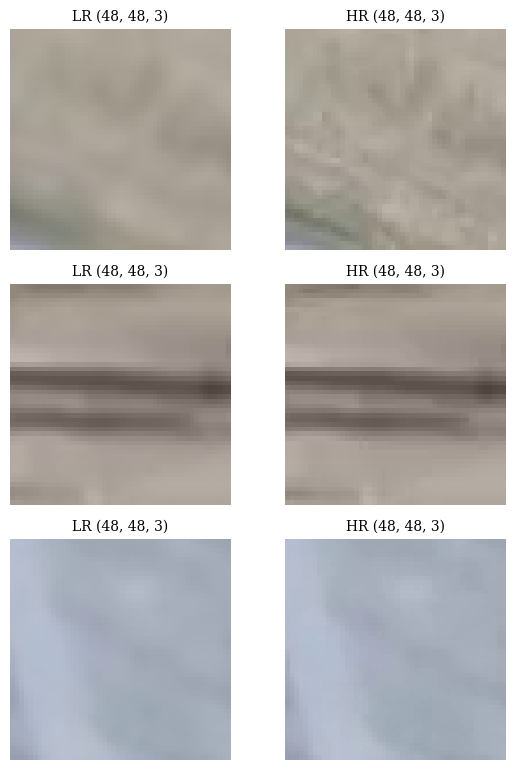

In [3]:
# What the model is actually fed: input on the left, its target on the right.
_ = plot_patch_pairs(X_train, Y_train, count=3, seed=0)

In [4]:
model = SRCNNModel()

model.setup_model(input_shape=X_train.shape[1:], learning_rate=1e-4)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 48, 48, 96)        23424     
                                                                 
 conv2d_1 (Conv2D)           (None, 48, 48, 32)        3104      
                                                                 
 conv2d_2 (Conv2D)           (None, 48, 48, 3)         2403      
                                                                 
Total params: 28,931
Trainable params: 28,931
Non-trainable params: 0
_________________________________________________________________


In [5]:
# Train SRCNN and capture callbacks for metrics
history, time_cb, mem_cb = model.fit(
    X_train, Y_train, X_val, Y_val,
    batch_size=32,
    epochs=100
)

Training on GPU: /physical_device:GPU:0
Epoch 1/100
1429/1429 [==============================] - 20s 9ms/step - loss: 0.0067 - psnr: 25.6623 - ssim: 0.7041 - val_loss: 0.0024 - val_psnr: 27.8265 - val_ssim: 0.7459 - lr: 1.0000e-04 - epoch_time_sec: 19.9824 - gpu_mean_current_mb: 2410.5447 - gpu_peak_mb: 2844.8555
Epoch 2/100
1429/1429 [==============================] - 12s 8ms/step - loss: 0.0023 - psnr: 28.0736 - ssim: 0.7458 - val_loss: 0.0023 - val_psnr: 28.1526 - val_ssim: 0.7504 - lr: 1.0000e-04 - epoch_time_sec: 11.6564 - gpu_mean_current_mb: 2679.3044 - gpu_peak_mb: 2857.9954
Epoch 3/100
1429/1429 [==============================] - 11s 8ms/step - loss: 0.0022 - psnr: 28.2968 - ssim: 0.7477 - val_loss: 0.0022 - val_psnr: 28.2813 - val_ssim: 0.7525 - lr: 1.0000e-04 - epoch_time_sec: 11.4622 - gpu_mean_current_mb: 2679.3044 - gpu_peak_mb: 2857.6802
Epoch 4/100
1429/1429 [==============================] - 13s 9ms/step - loss: 0.0022 - psnr: 28.3786 - ssim: 0.7486 - val_loss: 0.0022 

In [6]:
del X_train, Y_train, X_val, Y_val  # Free memory
gc.collect()  # Force garbage collection to free memory

1488

In [7]:
# Evaluates the run, saves the checkpoint, the HR frame size and the metrics
# under one timestamp, so the reporting notebooks resolve a single run.
timestamp, run_dir, metrics = model.evaluate_and_save(
    X_test, Y_test, history, time_cb, mem_cb, hr_h, hr_w,
)


 SRCNN run 20260914_124219
  evaluating on the test partition
397/397 [==============================] - 2s 6ms/step - loss: 0.0020 - psnr: 28.8874 - ssim: 0.7617
Loss: 0.0020, PSNR: 28.89 dB, SSIM: 0.7617
Model saved to c:\Users\bgmanuel\MasterInteligenciaArtificial\Periodo2\TFM\Super-Resolution-Images-for-3D-Printing-Defect-Detection\models\SRCNN\SRCNN_20260914_124219\SRCNN_20260914_124219.h5
  frame size -> c:\Users\bgmanuel\MasterInteligenciaArtificial\Periodo2\TFM\Super-Resolution-Images-for-3D-Printing-Defect-Detection\models\SRCNN\SRCNN_20260914_124219\SRCNN_20260914_124219_hrh_hrw.pkl
  metrics    -> c:\Users\bgmanuel\MasterInteligenciaArtificial\Periodo2\TFM\Super-Resolution-Images-for-3D-Printing-Defect-Detection\models\SRCNN\SRCNN_20260914_124219\SRCNN_20260914_124219_metrics.pkl
  done in 2.9s

